In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

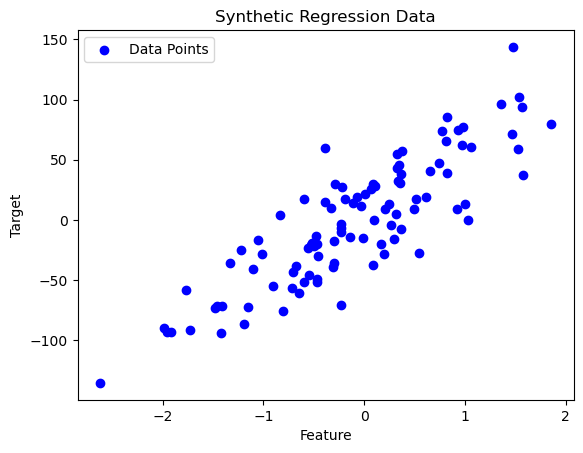

In [2]:
# Generate synthetic regression data
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=30, random_state=42)
# Visualize the data
plt.scatter(X, y, color='blue', label='Data Points')
plt.title('Synthetic Regression Data')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()

In [3]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((80, 1), (20, 1))

In [4]:
from sklearn.linear_model import LinearRegression
# Create a Linear Regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train, y_train)
# Print the coefficients and intercept
print(f'Coefficient: {model.coef_[0]:}')
print(f'Intercept: {model.intercept_:}')

Coefficient: 49.25034583816681
Intercept: 0.2976666426776351


In [5]:
# Predict on the test set
y_pred = model.predict(X_test)
# Print the R^2 score
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:}')

R^2 Score: 0.6538826156165654


**Making a custom class or to be very precise our own gradient descent class**

In [15]:
class GradientDescent:
    def __init__ (self, learning_rate, epochs):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coef_ = 100 # Assuming a starting coefficient(m)
        self.intercept_ = -150 # Assuming a starting intercept(b/c)

    # Fit the model to the data
    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slope_intercept = -2 * np.sum(y - self.coef_ * X.ravel() - self.intercept_)
            loss_slope_coef = -2 * np.sum((y - self.coef_ * X.ravel() - self.intercept_) * X.ravel())
            self.intercept_ = self.intercept_ - self.learning_rate * loss_slope_intercept
            self.coef_ = self.coef_ - self.learning_rate * loss_slope_coef
        print(f'Final Coefficient: {self.coef_}')
        print(f'Final Intercept: {self.intercept_}')
    
    # Predict using the fitted model
    def predict(self, X):
        return self.coef_ * X.ravel() + self.intercept_


In [17]:
gd_model = GradientDescent(learning_rate=0.01, epochs=500)

In [18]:
gd_model.fit(X_train, y_train)

Final Coefficient: 49.250345838166815
Final Intercept: 0.2976666426776363


In [19]:
y_pred_gd = gd_model.predict(X_test)
r2_gd = r2_score(y_test, y_pred_gd)
print(f'R^2 Score for Gradient Descent: {r2_gd:}')

R^2 Score for Gradient Descent: 0.6538826156165654
